In [1]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
from pathlib import Path

num_batches = 200

data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/data/data_uni_nf/')

coord_list = []
current_list = []
voltage_list = []
input_idx = 0

for i in range(num_batches):
    fp = data_dir / f'dataset_batch_{i:04d}.pt'
    data = torch.load(fp, weights_only=False, map_location='cpu')
    coord_list.append(data['X'])
    current_list.append(data['y'])
    voltage_list.append(data['V'][..., input_idx].reshape(-1, 1))

coord_set = np.concatenate(coord_list)
current_set = np.concatenate(current_list)
voltage_set = np.concatenate(voltage_list)

print('Dataset loaded')

Dataset loaded


In [48]:
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.utils.data import random_split
from train_sm import MakeDataset

train_size = 0.8
val_size = 0.1
test_size = 0.1

r2 = np.sum(coord_set**2, axis=-1)
print(r2.max())
idx = np.argsort(r2, axis=1)
sorted_coord_set = np.take_along_axis(
    coord_set,
    idx[..., None],
    axis=1
)

X = torch.from_numpy(sorted_coord_set).float()
C = torch.from_numpy(np.concatenate([voltage_set, current_set.reshape(-1, 1)], axis=1)).float()

X = X[:10000, ...]
C = C[:10000, ...]

print(current_set.max(), current_set.min())

print(X.shape)
print(C.shape)

dataset = TensorDataset(X, C)

generator_1 = torch.Generator().manual_seed(666)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

batch_size = 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=6, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=6, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=6, pin_memory=True)

print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))
print('Dataloaders ready')

0.99999994
1.1268212 -0.9519929
torch.Size([10000, 200, 2])
torch.Size([10000, 2])
8000
1000
1000
Dataloaders ready


In [36]:
import normflows as nf

K = 16

latent_size = 400
hidden_units = 128
hidden_layers = 5

flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units)]
    flows += [nf.flows.LULinearPermute(latent_size)]

q0 = nf.distributions.DiagGaussian(latent_size, trainable=False)
    
nfm = nf.NormalizingFlow(q0=q0, flows=flows)

nfm = nfm.to(device)

In [49]:
num_epochs = 50

optimizer = torch.optim.Adam(nfm.parameters(), lr=1e-3)

train_losses = []
val_losses = []

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        nfm.train()
        train_loss = 0.0
        n_train = 0
        for x, c in train_loader:
            x = x.reshape(-1, 200*2)
            x = x.to(device)       
            c = c.to(device)
    
            loss = nfm.forward_kld(x)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            batch_size = x.size(0)
            train_loss += loss.item() * batch_size
            n_train += batch_size

        train_loss /= n_train
        train_losses.append(train_loss)
    
        nfm.eval()
        val_loss = 0.0
        n_val = 0
    
        with torch.no_grad():
            for x_val, c_val in val_loader:
                x_val = x_val.reshape(-1, 200*2)
                x_val = x_val.to(device)
                c_val = c_val.to(device)
    
                loss_val = nfm.forward_kld(x_val)
                
                batch_size = x_val.size(0)
                val_loss += loss_val.item() * batch_size
                n_val += batch_size
    
        val_loss /= n_val
        val_losses.append(val_loss)
    
        pbar.set_postfix({
            "Epoch": f"{epoch:03d}",
            "train NLL": f"{train_loss:.4f}",
            "val NLL": f"{val_loss:.4f}"
        })
        pbar.update(1)

Epochs:   8%|▊         | 4/50 [00:27<05:14,  6.84s/it, Epoch=004, train NLL=131.0960, val NLL=154.7431]


KeyboardInterrupt: 

(100, 200, 2)


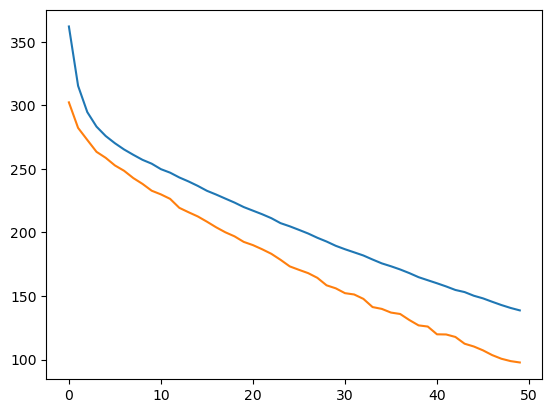

In [38]:
import matplotlib.pyplot as plt

torch.save(nfm.state_dict(), f='/gpfs/bwfor/work/ws/hd_gy283-my_data/models/spline_flow.pth')
plt.plot(train_losses)
plt.plot(val_losses)
nfm.eval()

num_samples = 100

with torch.no_grad():
    x, _ = nfm.sample(num_samples=100)

x = x.detach().cpu().numpy().reshape(-1, 200, 2)
print(x.shape)

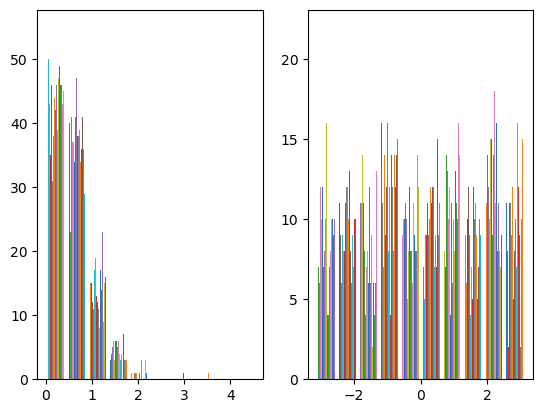

(100, 200, 2)


In [41]:
x_coords = x.reshape(-1, 2)
radii = np.linalg.norm(x, axis=-1)
thetas = np.atan2(x[..., 1], x[..., 0])

bins=10
fig, ax = plt.subplots(ncols=2)
ax[0].hist(radii**2, bins=bins)
ax[1].hist(thetas, bins=bins)
plt.show()

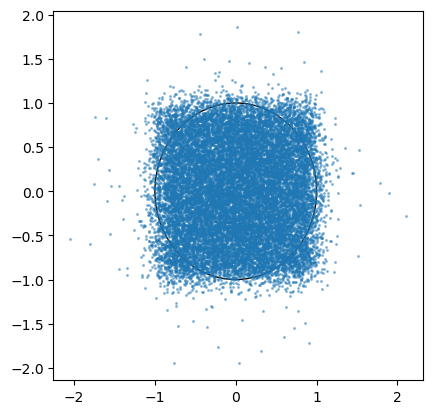

In [47]:
import matplotlib.patches as ps

fig, ax = plt.subplots()
ax.set_box_aspect(1)
ax.add_patch(ps.Circle(xy=(0,0), radius=1.0, fill=None))
ax.scatter(*x.T, s=1.5, alpha=.4)